Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

### Importing Skin Cancer Data
#### To do: Take necessary actions to read the data

### Importing all the important libraries

In [1]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Flatten, Conv2D, MaxPooling2D

In [2]:
## If you are using the data by mounting the google drive, use the following :
from google.colab import drive
drive.mount('/content/drive')

##Ref:https://towardsdatascience.com/downloading-datasets-into-google-drive-via-google-colab-bcb1b30b0166

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [3]:
# Changing the directory
%cd /content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment

/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment


In [4]:
# Defining the path for train and test images
## Todo: Update the paths of the train and test dataset
data_dir_train = pathlib.Path("/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train")
data_dir_test = pathlib.Path("/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Test")

In [5]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


### Load using keras.preprocessing

Let's load these images off disk using the helpful image_dataset_from_directory utility.

### Create a dataset

Define some parameters for the loader:

In [6]:
batch_size = 32
img_height = 180
img_width = 180

Use 80% of the images for training, and 20% for validation.

In [7]:
## Write your train dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = 'training',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


In [8]:
## Write your validation dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = 'validation',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


In [9]:
# List out all the classes of skin cancer and store them in a list.
# You can find the class names in the class_names attribute on these datasets.
# These correspond to the directory names in alphabetical order.
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [10]:
# Checking for batch size and image size
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


### Visualize the data
#### Todo, create a code to visualize one instance of all the nine classes present in the dataset

(32, 180, 180, 3)
(32,)


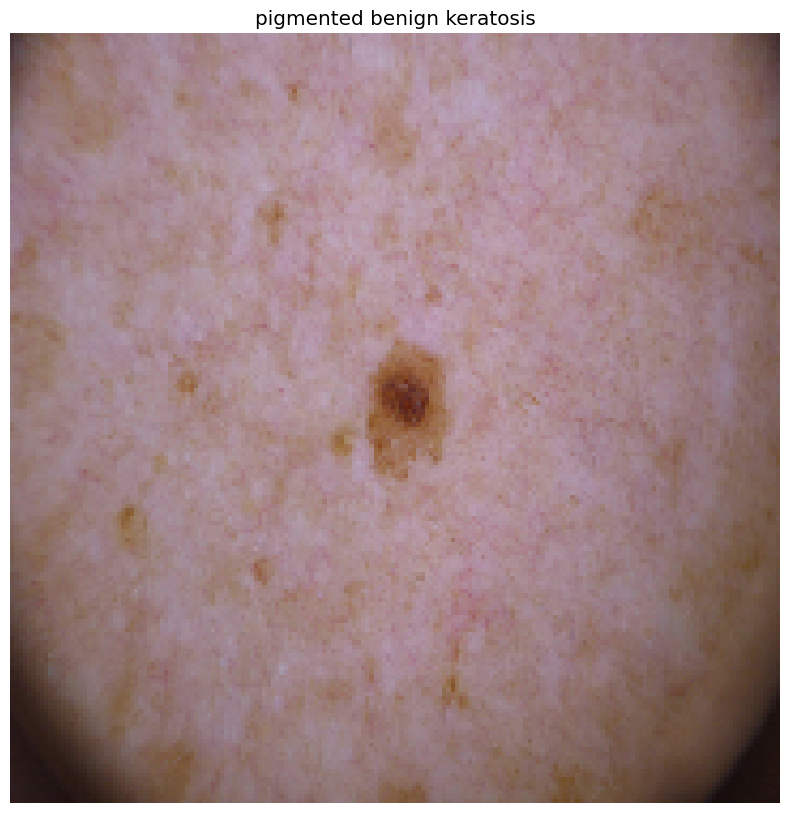

In [11]:
### your code goes here, you can use training or validation data to visualize

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  print(images.shape)
  print(labels.shape)
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.title(class_names[labels[0]])
  plt.axis("off")

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

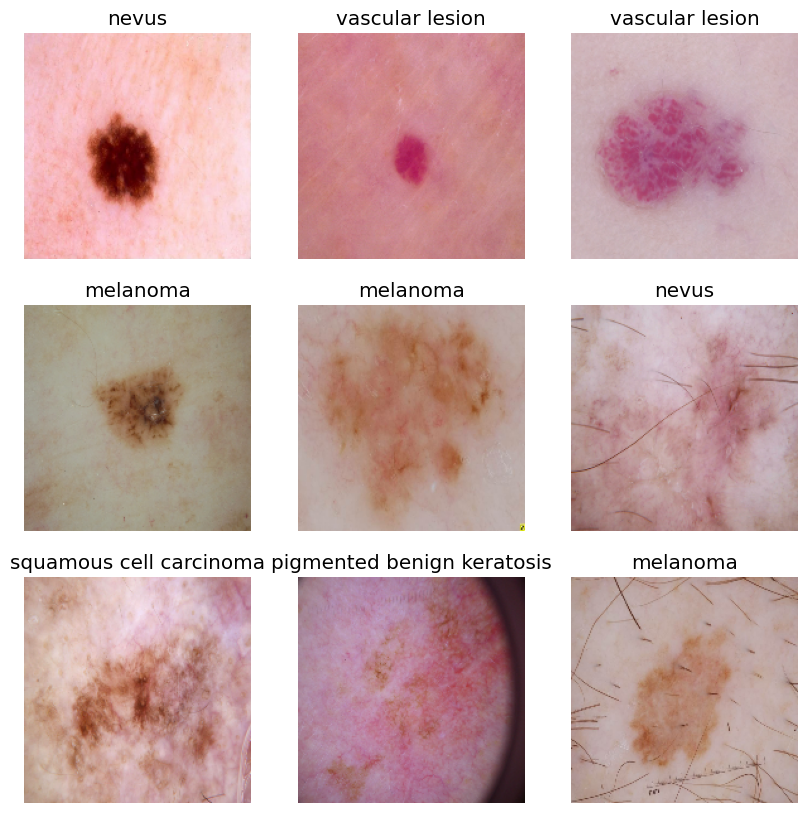

In [12]:
# Checking images for a sample of batch size
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [13]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model
#### Todo: Create a CNN model, which can accurately detect 9 classes present in the dataset. Use ```layers.experimental.preprocessing.Rescaling``` to normalize pixel values between (0,1). The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network. Here, it is good to standardize values to be in the `[0, 1]`



---
The 1st iteration of the model does not have any dropout or batchnormalization introduced.

In [14]:

### Building the base model
model = Sequential([
    # rescaling the data to normalize the pixel size
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolution Layer
    layers.Conv2D(16, 3, padding='same', activation='relu'),

    # First Max pooling layer
    layers.MaxPooling2D(),

    # Second Convolution Layer
    layers.Conv2D(32, 3, padding='same', activation='relu'),

    # Second Max pooling layer
    layers.MaxPooling2D(),

    # Third Convolution Layer
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # Third Max Poolin Layer
    layers.MaxPooling2D(),

    # Flattening to convert the 2D feature matrix to a 1D feature vector
    layers.Flatten(),

    #Fully connected layer
    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names))
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compile the model
Choose an appropirate optimiser and loss function for model training

In [15]:
### Todo, choose an appropirate optimiser and loss function
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [16]:
# View the summary of all layers
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [17]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 119s 458ms/step - accuracy: 0.1969 - loss: 2.0386 - val_accuracy: 0.3915 - val_loss: 1.7579
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4340 - loss: 1.6119 - val_accuracy: 0.4116 - val_loss: 1.6815
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4781 - loss: 1.5092 - val_accuracy: 0.4899 - val_loss: 1.4851
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5321 - loss: 1.3583 - val_accuracy: 0.4877 - val_loss: 1.4979
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5359 - loss: 1.2792 - val_accuracy: 0.5302 - val_loss: 1.3888
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5927 - loss: 1.1503 - val_accuracy: 0.4899 - val_loss: 1.4897
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6029 - loss: 1.1393 - val_accuracy: 0.4966 - val_loss: 1.5042
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6378 - loss: 0.9972 - val_accuracy: 0.5280 

### Visualizing training results

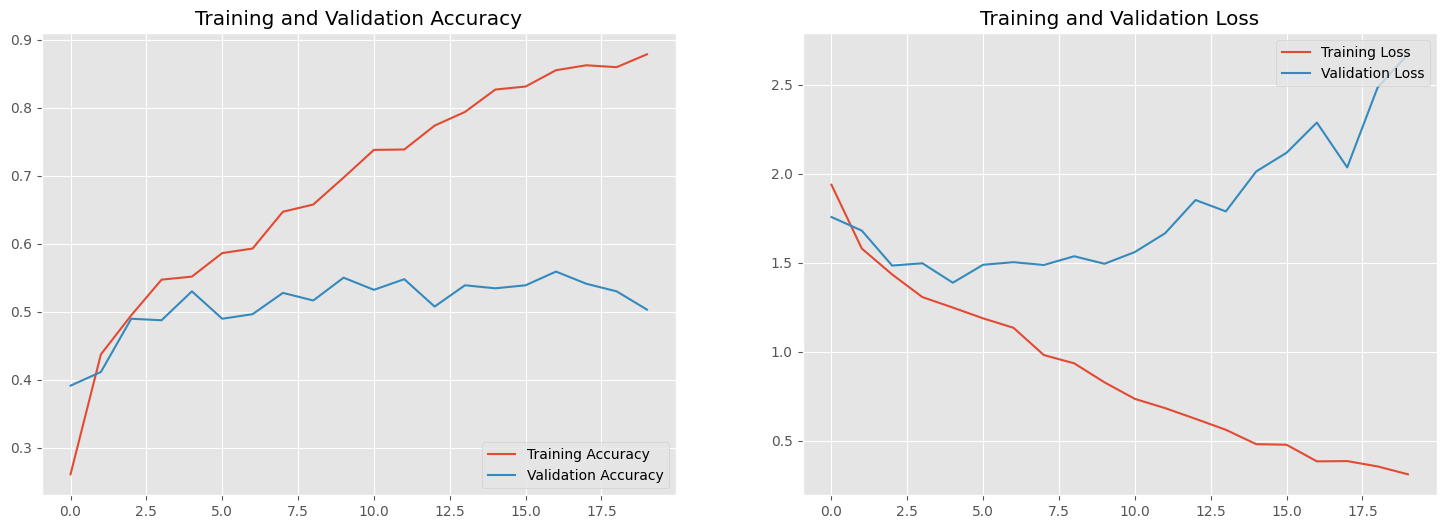

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit


---


From the intial model run following are the findings:

The model is overfitting which is evident from the difference between the

1.   The model is overfitting which is evident from the difference between the training and valdation accuracy.
2.   The training accuracy improves almost exponentially but the validation accuracy improves after the initial epochs and later on there does not seem to be any incremental improvement.
3. The validation loss sees a steady decline in the initial epochs but then continues to increase.

### Running iteration with new network parameters
1. One Additional convolution layer added

In [19]:
### Building the base model
model = Sequential([
    # rescaling the data to normalize the pixel size
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolution Layer
    layers.Conv2D(32, 3, padding='same', activation='relu'),

    # First Max Pooling layer
    layers.MaxPooling2D(),

    # Second Convolution Layer
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # Second Max Pooling layer
    layers.MaxPooling2D(),

    # Third Convolution Layer
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    # Third Max Pooling Layer
    layers.MaxPooling2D(),

    # Fourth Convolution Layer
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # Third Max Pooling Layer
    layers.MaxPooling2D(),

    # Flattening to convert the 2D feature matrix to a 1D feature vector
    layers.Flatten(),

    #Fully connected layer
    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names))
])

In [20]:
### Todo, choose an appropirate optimiser and loss function
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 180, 180, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 90, 90, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 45, 45, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 22, 22, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 7744)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         991,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,159,561 (4.42 MB)

 Trainable params: 1,159,561 (4.42 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.1948 - loss: 2.0695 - val_accuracy: 0.2975 - val_loss: 1.8678
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3123 - loss: 1.8238 - val_accuracy: 0.4251 - val_loss: 1.6871
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3715 - loss: 1.7374 - val_accuracy: 0.4385 - val_loss: 1.5696
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4448 - loss: 1.5482 - val_accuracy: 0.4989 - val_loss: 1.4780
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4969 - loss: 1.4351 - val_accuracy: 0.4989 - val_loss: 1.4788
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5105 - loss: 1.4028 - val_accuracy: 0.4430 - val_loss: 1.5989
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5101 - loss: 1.3700 - val_accuracy: 0.5101 - val_loss: 1.4258
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5266 - loss: 1.2897 - val_accuracy: 0.4787 - v

### Write your findings here


---


1. Addition of extra convolution layer does not improve the model accuracy and the does not solve the overfitting issue.

## Image Augmentation

#### Trying to improve the current data with a image augmentation strategy. Trying an alternative strategy to make adjustment to iamge quality.

In [23]:
# Todo, after you have analysed the model fit history for presence of underfit or overfit, choose an appropriate data augumentation strategy.
# Trying to change current data with a few image augmentation strategies
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                                                 input_shape=(img_height,
                                                              img_width,
                                                              3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(1,.5, fill_mode="reflect",interpolation="bilinear", seed=None,fill_value=0.0),
    layers.RandomContrast(0.1),
    layers.RandomCrop(img_height,img_width),
  ]
)

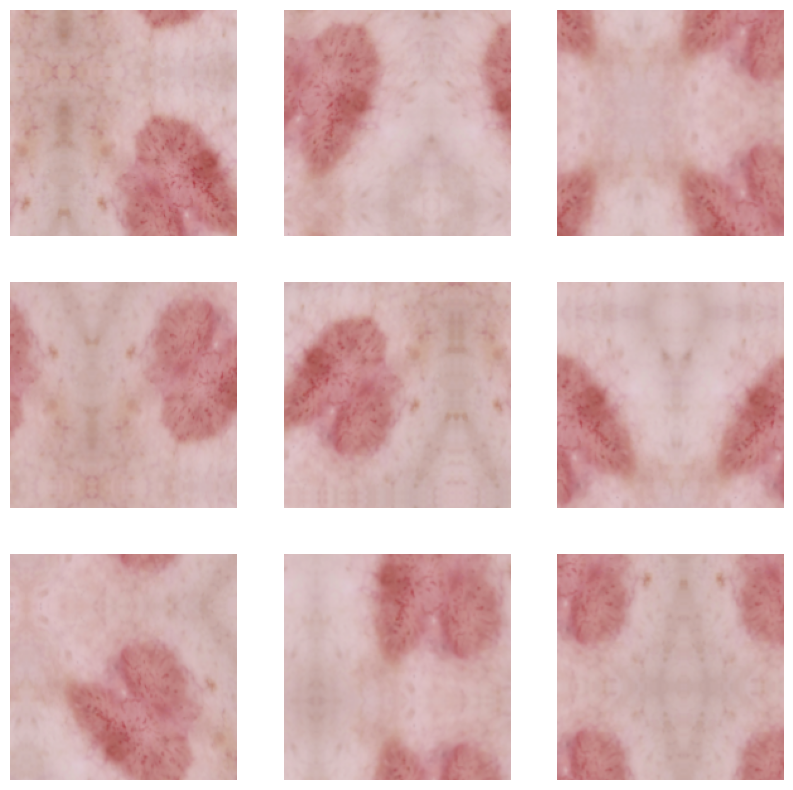

In [24]:
# Todo, visualize how your augmentation strategy works for one instance of training image.
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

### Todo:
### Create the model, compile and train the model


In [25]:
## You can use Dropout layer if there is an evidence of overfitting in your findings
### Building the base model post data augementation and using dropout layer
model = Sequential([
    data_augmentation,
    # rescaling the data to normalize the pixel size
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolution Layer
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # First Max pooling layer
    layers.MaxPooling2D(),

    # Second Convolution Layer
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    # Second Max pooling layer
    layers.MaxPooling2D(),

    # Third Convolution Layer
    layers.Conv2D(256, 3, padding='same', activation='relu'),

    # Third Max Poolin Layer
    layers.MaxPooling2D(),

    # Using a dropout layer
    layers.Dropout(0.2),

    # Flattening to convert the 2D feature matrix to a 1D feature vector
    layers.Flatten(),

    #Fully connected layer
    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names))
])

In [26]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_2 (Rescaling)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Compiling the model

In [27]:
### Todo, choose an appropirate optimiser and loss function
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

### Training the model

In [28]:
## Your code goes here, note: train your model for 20 epochs
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.2214 - loss: 2.2196 - val_accuracy: 0.2931 - val_loss: 1.7924
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3110 - loss: 1.8079 - val_accuracy: 0.3870 - val_loss: 1.7046
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3507 - loss: 1.6915 - val_accuracy: 0.3468 - val_loss: 1.6912
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3640 - loss: 1.6329 - val_accuracy: 0.3982 - val_loss: 1.6097
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3968 - loss: 1.6001 - val_accuracy: 0.4004 - val_loss: 1.5815
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.4078 - loss: 1.5670 - val_accuracy: 0.3624 - val_loss: 1.7340
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3768 - loss: 1.7003 - val_accuracy: 0.4094 - val_loss: 1.6136
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3955 - loss: 1.5745 - val_accuracy: 0.3378 - 

### Visualizing the results

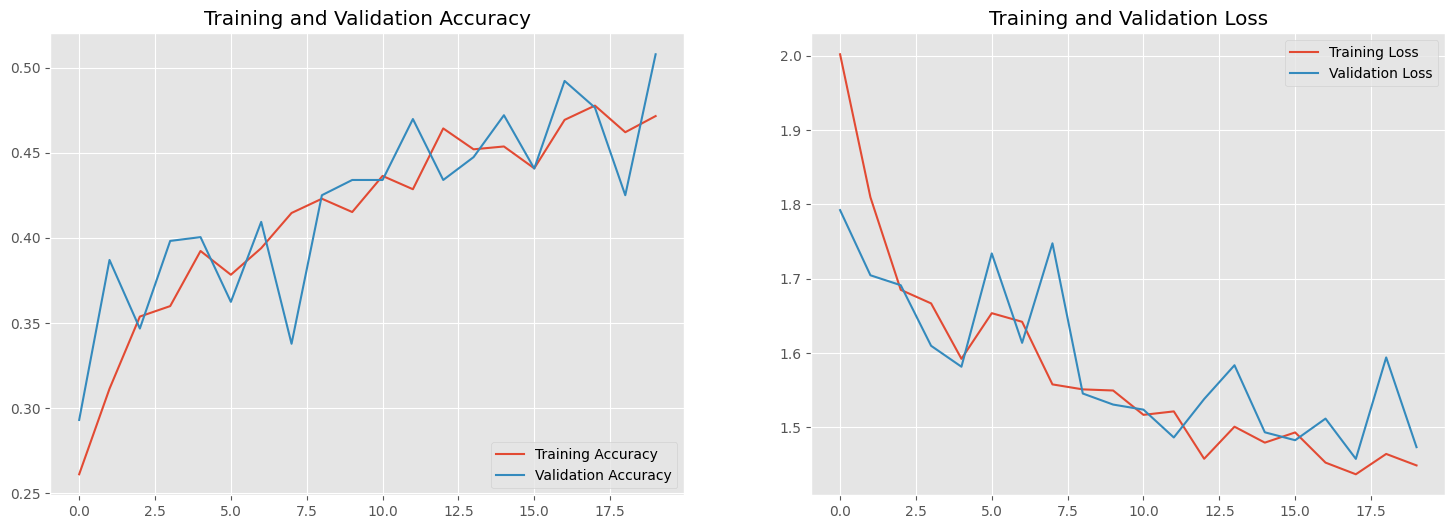

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit. Do you think there is some improvement now as compared to the previous model run?



---


The data augmentation strategy employed underfits the model as the accuracy deteriorates for both training and validation

In [30]:
train_dir = os.path.join("/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train")
test_dir = os.path.join("/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Test")

#### Trying out alternative image augmentation strategy

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# setting batch size and image size
batch_size = 100
IMG_SHAPE = 224

# Create data generator
image_gen_train = ImageDataGenerator(
      rescale=1./255,
      rotation_range=45,
      width_shift_range=.15,
      height_shift_range=.15,
      horizontal_flip=True,
      zoom_range=0.5
    )

train_data_gen = image_gen_train.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     shuffle=True,
                                                     target_size=(IMG_SHAPE,IMG_SHAPE),
                                                     class_mode='sparse')

image_gen_val = ImageDataGenerator(rescale=1./255)
val_data_gen = image_gen_val.flow_from_directory(batch_size=batch_size,
                                                 directory=test_dir,
                                                 target_size=(IMG_SHAPE, IMG_SHAPE),
                                                 class_mode='sparse')

Found 2239 images belonging to 9 classes.
Found 118 images belonging to 9 classes.


### Creating the model with the image augmentation

In [32]:
#Create a CNN model
#Experiment #1
#A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor
import numpy as np
import glob
import shutil
import matplotlib.pyplot as plt

# Import layers explicitly to keep our code compact
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D

model = Sequential()

#2D convolution layer (e.g. spatial convolution over images).
model.add(Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_SHAPE,IMG_SHAPE, 3)))
#Downsamples the input along its spatial dimensions (height and width) by taking the maximum value over an input window (of size defined by pool_size) for each channel of the input.
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, 3, padding='same', activation='relu'))

#Downsamples the input along its spatial dimensions (height and width) by taking the maximum value over an input window (of size defined by pool_size) for each channel of the input.
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, 3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

#Flattens the input. Does not affect the batch size.
model.add(Flatten())

#https://keras.io/api/layers/regularization_layers/dropout/
#The Dropout layer randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting. Inputs not set to 0 are scaled up by 1/(1 - rate) such that the sum over all inputs is unchanged
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))

model.add(Dropout(0.2))

#Just your regular densely-connected NN layer.
#Dense is the only actual network layer in that model. A Dense layer feeds all outputs from the previous layer to all its neurons, each neuron providing one output to the next layer.
#It's the most basic layer in neural networks. A Dense(10) has ten neurons. A Dense(512) has 512 neurons.
#Dense implements the operation: output = activation(dot(input, kernel)
model.add(Dense(9))

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model
epochs = 20

history = model.fit(
  train_data_gen,
  validation_data=val_data_gen,
  epochs=20
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.1737 - loss: 3.1308 - val_accuracy: 0.1864 - val_loss: 2.1692
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.2894 - loss: 1.9263 - val_accuracy: 0.1949 - val_loss: 2.3318
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.3059 - loss: 1.8639 - val_accuracy: 0.2458 - val_loss: 2.1631
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4062 - loss: 1.6790 - val_accuracy: 0.2881 - val_loss: 2.2145
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4455 - loss: 1.5654 - val_accuracy: 0.3051 - val_loss: 2.2926
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4783 - loss: 1.4807 - val_accuracy: 0.3220 - val_loss: 2.0935
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4884 - loss: 1.4593 - val_accuracy: 0.2797 - val_loss: 2.5825
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4869 - loss: 1.4520 - val_accuracy: 0.3220 - val_loss: 2.0419
Ep



---


#### Results improve slightly with change in batch size and new image augmentation strategy

#### **Todo:** Find the distribution of classes in the training dataset.
#### **Context:** Many times real life datasets can have class imbalance, one class can have proportionately higher number of samples compared to the others. Class imbalance can have a detrimental effect on the final model quality. Hence as a sanity check it becomes important to check what is the distribution of classes in the data.

In [33]:
from glob import glob
path_list = [x for x in glob(os.path.join(data_dir_train, '*', '*.jpg'))]
lesion_list = [os.path.basename(os.path.dirname(y)) for y in glob(os.path.join(data_dir_train, '*', '*.jpg'))]
len(path_list)

2239

In [34]:
dataframe_dict_original = dict(zip(path_list, lesion_list))
original_df = pd.DataFrame(list(dataframe_dict_original.items()),columns = ['Path','Label'])
original_df

,Path,Label
0,/content/drive/MyDrive/Convolutional_Neural_Ne...,vascular lesion
1,/content/drive/MyDrive/Convolutional_Neural_Ne...,vascular lesion
2,/content/drive/MyDrive/Convolutional_Neural_Ne...,vascular lesion
3,/content/drive/MyDrive/Convolutional_Neural_Ne...,vascular lesion
4,/content/drive/MyDrive/Convolutional_Neural_Ne...,vascular lesion
...,...,...
2234,/content/drive/MyDrive/Convolutional_Neural_Ne...,actinic keratosis
2235,/content/drive/MyDrive/Convolutional_Neural_Ne...,actinic keratosis
2236,/content/drive/MyDrive/Convolutional_Neural_Ne...,actinic keratosis
2237,/content/drive/MyDrive/Convolutional_Neural_Ne...,actinic keratosis


In [35]:
round(original_df.Label.value_counts(normalize=True)*100,2)

Label
pigmented benign keratosis    20.63
melanoma                      19.56
basal cell carcinoma          16.79
nevus                         15.94
squamous cell carcinoma        8.08
vascular lesion                6.21
actinic keratosis              5.09
dermatofibroma                 4.24
seborrheic keratosis           3.44
Name: proportion, dtype: float64

Class=8, n=139 (6.208%)
Class=7, n=181 (8.084%)
Class=6, n=77 (3.439%)
Class=5, n=462 (20.634%)
Class=4, n=357 (15.945%)
Class=3, n=438 (19.562%)
Class=2, n=95 (4.243%)
Class=1, n=376 (16.793%)
Class=0, n=114 (5.092%)


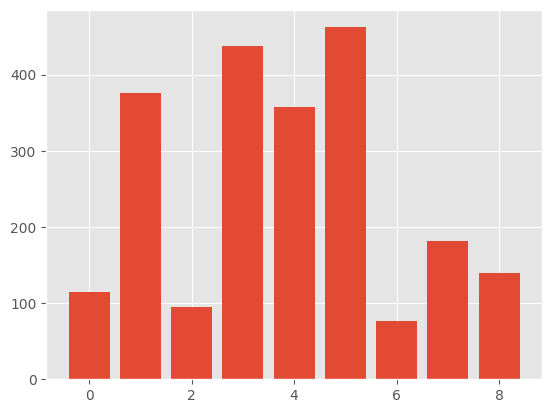

In [36]:
## Your code goes here.
from sklearn.preprocessing import LabelEncoder
from collections import Counter
# split data into X and y
X, y = original_df['Path'], original_df['Label']
# Label encoding the target variable
y = LabelEncoder().fit_transform(y)
# creating a distribution summary
counter = Counter(y)
for k,v in counter.items():
    per = v / len(y) * 100
    print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the distribution
plt.bar(counter.keys(), counter.values())
plt.show()

#### **Todo:** Write your findings here:
#### - Which class has the least number of samples?
1. Seborrheic Keratosis has least number of samples.

#### - Which classes dominate the data in terms proportionate number of samples?
2. Pigmented Benign Keratosis has the maximum proportion of classes



In [37]:
# Creating the weights as per the class distribution in data
unique_values = list(np.unique(y))
proportion_of_classes = []
for i in unique_values:
    count = np.sum(y == i)
    proportion_of_classes.append(round((count / len(y))*100,2))
class_weight = dict(zip(unique_values, proportion_of_classes))
class_weight

{0: 5.09,
 1: 16.79,
 2: 4.24,
 3: 19.56,
 4: 15.94,
 5: 20.63,
 6: 3.44,
 7: 8.08,
 8: 6.21}

In [38]:
### Building the base model post data augementation and using dropout layer
model = Sequential([
    # rescaling the data to normalize the pixel size
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolution Layer
    layers.Conv2D(16, 3, padding='same', activation='relu'),

    # First Max pooling layer
    layers.MaxPooling2D(),

    # Second Convolution Layer
    layers.Conv2D(32, 3, padding='same', activation='relu'),

    # Second Max pooling layer
    layers.MaxPooling2D(),

    # Third Convolution Layer
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # Third Max Poolin Layer
    layers.MaxPooling2D(),

    # Using a dropout layer
    #layers.Dropout(0.2),

    # Flattening to convert the 2D feature matrix to a 1D feature vector
    layers.Flatten(),

    #Fully connected layer
    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names))
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [41]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  class_weight=class_weight)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2218 - loss: 30.1300 - val_accuracy: 0.2975 - val_loss: 2.0480
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3442 - loss: 22.4043 - val_accuracy: 0.4832 - val_loss: 1.6415
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4976 - loss: 17.6392 - val_accuracy: 0.5034 - val_loss: 1.6258
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5026 - loss: 17.1748 - val_accuracy: 0.4855 - val_loss: 1.6742
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5495 - loss: 15.5772 - val_accuracy: 0.4922 - val_loss: 1.7093
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5597 - loss: 15.3785 - val_accuracy: 0.5235 - val_loss: 1.5500
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6148 - loss: 12.8108 - val_accuracy: 0.5257 - val_loss: 1.3817
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6178 - loss: 12.2314 - val_accuracy: 0.



---

Using weights proportinal to class distribution improves the accuracy and generalization slightly.


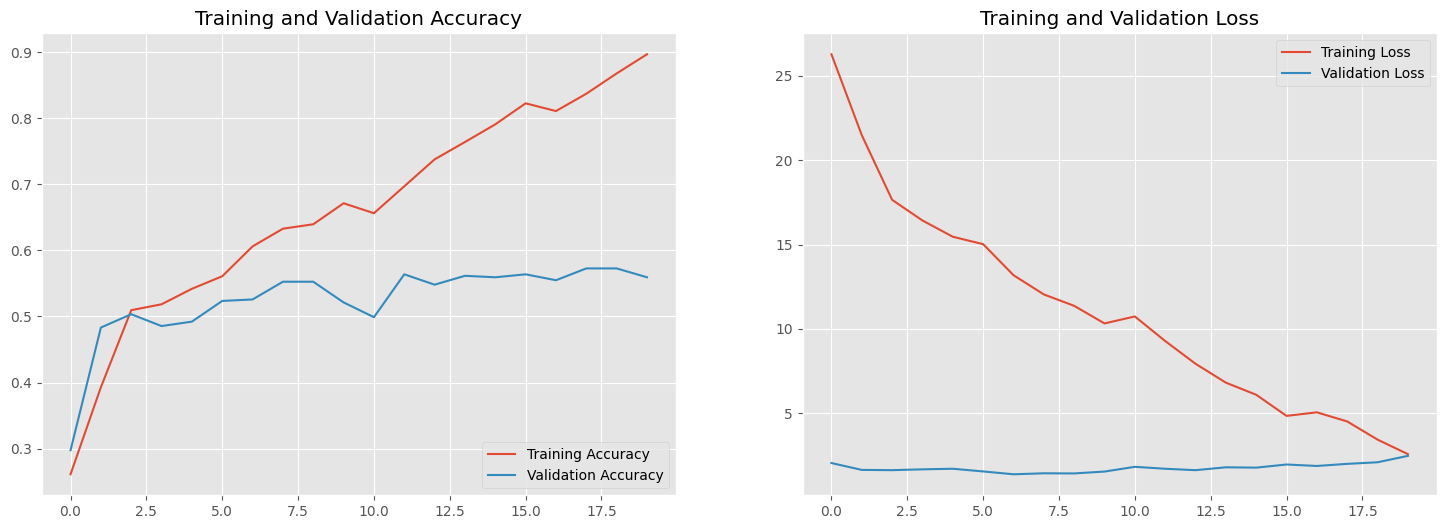

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### **Todo:** Rectify the class imbalance
#### **Context:** You can use a python package known as `Augmentor` (https://augmentor.readthedocs.io/en/master/) to add more samples across all classes so that none of the classes have very few samples.

In [43]:
!pip install Augmentor

To use `Augmentor`, the following general procedure is followed:

1. Instantiate a `Pipeline` object pointing to a directory containing your initial image data set.<br>
2. Define a number of operations to perform on this data set using your `Pipeline` object.<br>
3. Execute these operations by calling the `Pipeline’s` `sample()` method.


In [44]:
data_dir_train_augm = pathlib.Path("/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train")
data_dir_test_augm = pathlib.Path("/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Test")

In [45]:
path_to_training_dataset="/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train//"
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

Initialised with 114 image(s) found.
Output directory set to /content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train//actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7AFF903E03D0>: 100%|██████████| 500/500 [00:04<00:00, 111.30 Samples/s]


Initialised with 376 image(s) found.
Output directory set to /content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train//basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7AFF90491660>: 100%|██████████| 500/500 [00:04<00:00, 106.07 Samples/s]


Initialised with 95 image(s) found.
Output directory set to /content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train//dermatofibroma/output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7AFF903C6B00>: 100%|██████████| 500/500 [00:07<00:00, 71.41 Samples/s]


Initialised with 181 image(s) found.
Output directory set to /content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train//squamous cell carcinoma/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7AFFC9FDA110>: 100%|██████████| 500/500 [00:04<00:00, 110.21 Samples/s]


Initialised with 139 image(s) found.
Output directory set to /content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train//vascular lesion/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7AFF9025AA10>: 100%|██████████| 500/500 [00:04<00:00, 109.71 Samples/s]


Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. Lets take a look at total count of augmented images.

In [46]:
image_count_train = len(list(data_dir_train_augm.glob('*/output/*.jpg')))
print(image_count_train)

4500


### Lets see the distribution of augmented data after adding new images to the original training data.

In [47]:
path_list = [x for x in glob(os.path.join(data_dir_train_augm, '*','output', '*.jpg'))]
path_list

['/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train/vascular lesion/output/vascular lesion_original_ISIC_0030070.jpg_bbda8df8-3c28-4dbc-a33d-c730f1a5ffc6.jpg',
 '/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train/vascular lesion/output/vascular lesion_original_ISIC_0033591.jpg_18d0e06c-b3b3-4c51-8b8e-d0fb2ce14b73.jpg',
 '/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train/vascular lesion/output/vascular lesion_original_ISIC_0033123.jpg_e8392d25-ed27-4905-a96a-5e267c07178a.jpg',
 '/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignm

In [48]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_dir_train_augm, '*','output', '*.jpg'))]
lesion_list_new

['vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',
 'vascular lesion',


In [49]:
dataframe_dict_new = dict(zip(path_list, lesion_list_new))

In [50]:
df2 = pd.DataFrame(list(dataframe_dict_new.items()),columns = ['Path','Label'])
new_df = pd.concat([original_df, df2],ignore_index=True)

In [51]:
new_df['Label'].value_counts()

Label
pigmented benign keratosis    962
melanoma                      938
basal cell carcinoma          876
nevus                         857
squamous cell carcinoma       681
vascular lesion               639
actinic keratosis             614
dermatofibroma                595
seborrheic keratosis          577
Name: count, dtype: int64

So, now we have added 500 images to all the classes to maintain some class balance. We can add more images as we want to improve training process.

#### **Todo**: Train the model on the data created using Augmentor

In [52]:
batch_size = 32
img_height = 180
img_width = 180

#### **Todo:** Create a training dataset

In [53]:
# data_dir_train="/content/drive/MyDrive/Convolutional_Neural_Network/Convolutional-Neural-Networks-main/Melanoma_Detection_Assignment/Skin_cancer_ISIC_The_International_Skin_Imaging_Collaboration/Train"
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train_augm,
  seed=123,
  validation_split = 0.2,
  subset = "training",
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


#### **Todo:** Create a validation dataset

In [54]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train_augm,
  seed=123,
  validation_split = 0.2,
  subset = "validation",
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


In [55]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#### **Todo:** Create your model (make sure to include normalization)

In [56]:
model = Sequential([
    # rescaling the data to normalize the pixel size
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Convolution Layer
    layers.Conv2D(16, 3, padding='same', activation='relu'),

    # First Max pooling layer
    layers.MaxPooling2D(),

    # Second Convolution Layer
    layers.Conv2D(32, 3, padding='same', activation='relu'),

    # Second Max pooling layer
    layers.MaxPooling2D(),

    # Third Convolution Layer
    layers.Conv2D(64, 3, padding='same', activation='relu'),

    # Third Max Poolin Layer
    layers.MaxPooling2D(),

    # Using a dropout layer
    layers.Dropout(0.2),

    # Flattening to convert the 2D feature matrix to a 1D feature vector
    layers.Flatten(),

    #Fully connected layer
    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names))
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

#### **Todo:** Compile your model (Choose optimizer and loss function appropriately)

In [58]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#### **Todo:**  Train your model

In [59]:
epochs = 30
## Your code goes here, use 50 epochs.
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.2121 - loss: 2.0492 - val_accuracy: 0.4684 - val_loss: 1.4559
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4842 - loss: 1.4162 - val_accuracy: 0.5561 - val_loss: 1.2256
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5891 - loss: 1.1455 - val_accuracy: 0.6117 - val_loss: 1.1252
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6609 - loss: 0.9417 - val_accuracy: 0.6756 - val_loss: 0.9382
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7144 - loss: 0.7907 - val_accuracy: 0.7082 - val_loss: 0.8490
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7909 - loss: 0.5984 - val_accuracy: 0.6837 - val_loss: 0.9274
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8188 - loss: 0.5182 - val_accuracy: 0.7491 - val_loss: 0.7680
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8685 - loss: 0.3761 - val_acc

#### **Todo:**  Visualize the model results

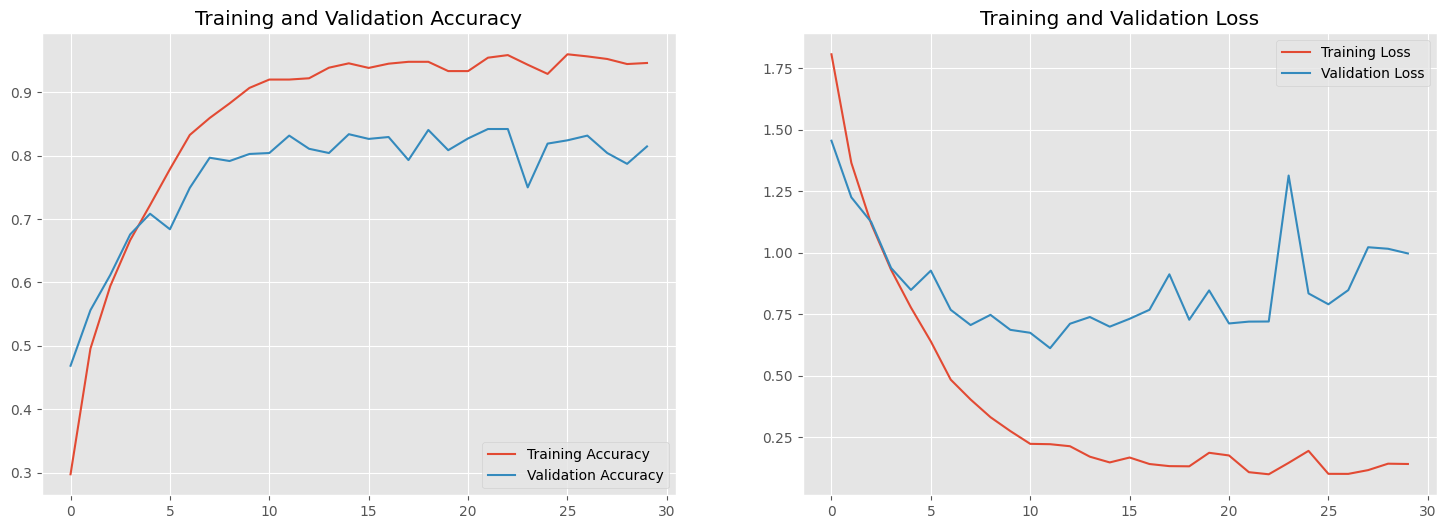

In [60]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### **Todo:**  Analyze your results here. Did you get rid of underfitting/overfitting? Did class rebalance help?




---

The class rebalance greatly helps in improving the overall accuracy and the overfitting issue is also resolved with significant improvement in validation accuracy.
